# BA scenario metrics generation

Reconstruct the released MISO hourly scenario metrics from historical load and renewable CF, using the 2024 reference fleet. The five main steps align the ingredients, apply renewable losses, calculate six capacity portfolios, and check the complete result against the archive.

**Inputs:** historical 2007–2023 MISO load, wind CF, solar CF, scenario metadata, and loss assumptions. The additional comparison uses 2022 EIA-930 observations and capacities.

**Requirements:** The repository environment and extracted historical archive; no weather-service access or model training is needed.

**Outputs:** a reconstructed MISO scenario CSV and a June 2022 comparison figure under `data_outputs/data_flow/ba_scenario_metrics_generation/`; inline archive checks. These examples do not replace the released products.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

State load is demonstrated in [state load generation](state_load_generation.ipynb), and renewable CF aggregation in Appendix A of [site CF generation and weighting](site_cf_generation_ba_weighting_validation.ipynb). Packaged state scenario metrics combine those ingredients using the same six nameplate-capacity portfolios.


## Setup

The complete paths below identify the fixed MISO example. Generated CSVs and figures go to the notebook output directory.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Fixed MISO example: 2024 fleet, historical 2007-2023 weather and load.
component_paths = {
    "load_mw": Path(
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv"
    ),
    "wind_cf": Path(
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_wind_cf/MISO_wtk_bchrrr_nsrdb_2007_2023_wind_cf.csv"
    ),
    "solar_cf": Path(
        "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_solar_cf/MISO_wtk_bchrrr_nsrdb_2007_2023_solar_cf.csv"
    ),
}
OUTPUT_DIR = Path("../../data_outputs/data_flow/ba_scenario_metrics_generation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Read selected BA inputs

Step 1 reads MISO's installed capacities, loss assumptions, and three hourly ingredient files.


In [2]:
ba_scenario_metric_metadata = pd.read_csv(
    "../../manifests/ba_scenario_metric_metadata_manifest_wtk_bchrrr_nsrdb_2007_2023.csv",
    usecols=[
        "ba_code",
        "scenario",
        "installed_wind_capacity_mw",
        "installed_solar_capacity_mw",
        "wind_capacity_mw",
        "solar_capacity_mw",
    ],
)

# Installed capacities are BA-level facts repeated across the manifest's metric rows.
ba_metadata_summary = ba_scenario_metric_metadata.loc[
    ba_scenario_metric_metadata["ba_code"].eq("MISO")
].iloc[0]
wind_capacity_mw = float(ba_metadata_summary["installed_wind_capacity_mw"])
solar_capacity_mw = float(ba_metadata_summary["installed_solar_capacity_mw"])
total_capacity_mw = wind_capacity_mw + solar_capacity_mw

# Convert percentage losses to the multiplier applied to each hourly raw CF.
loss_assumptions = pd.read_csv(
    "../../data_inputs/model_parameters/net_load_loss_assumptions_2007_2023.csv"
)
ba_loss = loss_assumptions.set_index("ba").loc["MISO"]
wind_loss_multiplier = 1.0 - float(ba_loss["wind_loss_pct"]) / 100.0
solar_loss_multiplier = 1.0 - float(ba_loss["solar_loss_pct"]) / 100.0

# Parse each input's time column before joining the three hourly tables.
component_tables = {}
for column, path in component_paths.items():
    component_tables[column] = pd.read_csv(
        path,
        usecols=["time_utc", column],
        parse_dates=["time_utc"],
    )
print("Selected BA: MISO")
for ingredient, path in component_paths.items():
    print(f"Read {ingredient}: {path.as_posix()}")
display(
    pd.Series(
        {
            "Installed wind capacity (MW)": f"{wind_capacity_mw:,.1f}",
            "Installed solar capacity (MW)": f"{solar_capacity_mw:,.1f}",
            "Installed total capacity (MW)": f"{total_capacity_mw:,.1f}",
            "Wind loss multiplier (fraction)": f"{wind_loss_multiplier:.3f}",
            "Solar loss multiplier (fraction)": f"{solar_loss_multiplier:.3f}",
        },
        name="Value",
    )
    .rename_axis("Setting")
    .to_frame()
)

Selected BA: MISO
Read load_mw: ../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv
Read wind_cf: ../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_wind_cf/MISO_wtk_bchrrr_nsrdb_2007_2023_wind_cf.csv
Read solar_cf: ../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_solar_cf/MISO_wtk_bchrrr_nsrdb_2007_2023_solar_cf.csv


,Value
Setting,
Installed wind capacity (MW),"32,150.7"
Installed solar capacity (MW),"13,574.9"
Installed total capacity (MW),"45,725.6"
Wind loss multiplier (fraction),1.000
Solar loss multiplier (fraction),1.000


## Step 2: Build the base hourly table

Step 2 aligns MISO load, wind CF, and solar CF on `time_utc`. The inner joins retain only hours present in all three inputs. Renewable losses are then applied as `adjusted_cf = raw_cf * (1 - loss_pct / 100)` before any scenario capacity is introduced.


In [3]:
# Inner joins define the common hourly support shared by load, wind, and solar.
base = component_tables["load_mw"].merge(component_tables["wind_cf"], on="time_utc")
base = base.merge(component_tables["solar_cf"], on="time_utc")
base = base.sort_values("time_utc")
base = base.reset_index(drop=True)
# Losses alter renewable availability once, before scenario capacities convert CF to MW.
base["wind_cf"] *= wind_loss_multiplier
base["solar_cf"] *= solar_loss_multiplier

print(f"Aligned {len(base):,} base hourly rows.")
# Preview 00:00, 06:00, 12:00, and 18:00 UTC on the first day.
preview = base
preview = preview.loc[
    base["time_utc"].isin(pd.date_range("2007-01-01", periods=4, freq="6h", tz="UTC"))
]
preview = preview.set_index("time_utc")
preview = preview.rename_axis("Time (UTC)")
preview = preview.rename(
    columns={
        "load_mw": "Load (MW)",
        "wind_cf": "Wind CF (fraction)",
        "solar_cf": "Solar CF (fraction)",
    }
)
preview = preview.round({"Load (MW)": 1, "Wind CF (fraction)": 3, "Solar CF (fraction)": 3})
display(preview)

Aligned 148,920 base hourly rows.


,Load (MW),Wind CF (fraction),Solar CF (fraction)
Time (UTC),,,
2007-01-01 00:00:00+00:00,71102.7,0.939,0.000
2007-01-01 06:00:00+00:00,65130.2,0.948,0.000
2007-01-01 12:00:00+00:00,68243.7,0.868,0.000
2007-01-01 18:00:00+00:00,77573.7,0.299,0.322


## Step 3: Define scenario capacity mixes

Step 3 defines MISO's installed-capacity scenario and five synthetic wind/solar splits. The installed scenario preserves the observed technology mix; each synthetic scenario reallocates the same total renewable nameplate capacity. Six portfolios are demonstrated because MISO has both wind and solar in the reference fleet.

For every synthetic split, the wind and solar percentages are shares of the combined wind-plus-solar nameplate capacity. The combined nameplate total is held fixed; the percentages do not describe shares of hourly energy generation.


In [4]:
ARCHIVE_INSTALLED_SCENARIO = "installed_2024"
# Synthetic names encode the wind/solar shares of total renewable nameplate capacity.
split_wind_pct = [0, 25, 50, 75, 100]
# Row 0 preserves installed wind and solar; the remaining rows hold their combined total fixed.
scenario_rows = [
    {
        "scenario": ARCHIVE_INSTALLED_SCENARIO,
        "wind_capacity_mw": wind_capacity_mw,
        "solar_capacity_mw": solar_capacity_mw,
    }
]
for wind in split_wind_pct:
    scenario_rows.append(
        {
            "scenario": f"split_w{wind:02d}_s{100 - wind:02d}",
            "wind_capacity_mw": total_capacity_mw * wind / 100,
            "solar_capacity_mw": total_capacity_mw * (100 - wind) / 100,
        }
    )
scenario_specs = pd.DataFrame(scenario_rows)
# Percentage columns are descriptive labels used by the plot, not calculation inputs.
scenario_specs["total_capacity_mw"] = scenario_specs[["wind_capacity_mw", "solar_capacity_mw"]].sum(
    axis=1
)
scenario_specs["wind_pct"] = (
    100 * scenario_specs["wind_capacity_mw"] / scenario_specs["total_capacity_mw"]
)
scenario_specs["solar_pct"] = 100 - scenario_specs["wind_pct"]
SCENARIO_LABELS = {
    "installed_2024": "Installed 2024",
    "split_w00_s100": "0% wind / 100% solar",
    "split_w25_s75": "25% wind / 75% solar",
    "split_w50_s50": "50% wind / 50% solar",
    "split_w75_s25": "75% wind / 25% solar",
    "split_w100_s00": "100% wind / 0% solar",
}

preview = scenario_specs
preview = preview.replace({"scenario": SCENARIO_LABELS})
preview = preview.set_index("scenario")
preview = preview.rename_axis("Portfolio")
preview = preview.rename(
    columns={
        "wind_capacity_mw": "Wind capacity (MW)",
        "solar_capacity_mw": "Solar capacity (MW)",
        "total_capacity_mw": "Total capacity (MW)",
        "wind_pct": "Wind (%)",
        "solar_pct": "Solar (%)",
    }
)
preview = preview.round(1)
display(preview)

,Wind capacity (MW),Solar capacity (MW),Total capacity (MW),Wind (%),Solar (%)
Portfolio,,,,,
Installed 2024,32150.7,13574.9,45725.6,70.3,29.7
0% wind / 100% solar,0.0,45725.6,45725.6,0.0,100.0
25% wind / 75% solar,11431.4,34294.2,45725.6,25.0,75.0
50% wind / 50% solar,22862.8,22862.8,45725.6,50.0,50.0
75% wind / 25% solar,34294.2,11431.4,45725.6,75.0,25.0
100% wind / 0% solar,45725.6,0.0,45725.6,100.0,0.0


## Step 4: Calculate scenario metrics

Cross the six capacity definitions with every hourly row, then calculate:

$$G_w = CF_w C_w, \qquad G_s = CF_s C_s$$
$$L_{\mathrm{net}} = L - G_w - G_s, \qquad CF_{\mathrm{equiv}} = \frac{G_w + G_s}{C_w + C_s}.$$

Here $CF_w$ and $CF_s$ are loss-adjusted capacity factors; $C_w$ and $C_s$ are wind and solar nameplate capacities (MW). $G_w$, $G_s$, $L$, and $L_{\mathrm{net}}$ are generation, load, and net load in MW. These correspond to `wind_mw`, `solar_mw`, `load_mw`, `net_load_mw`, and `renew_cf_equiv` below.


In [5]:
# The cross join repeats every hour once for each of the six capacity portfolios.
notebook_scenarios = scenario_specs[
    ["scenario", "wind_capacity_mw", "solar_capacity_mw", "total_capacity_mw"]
].merge(base, how="cross")
# Technology generation equals loss-adjusted availability times scenario nameplate capacity.
notebook_scenarios["wind_mw"] = (
    notebook_scenarios["wind_cf"] * notebook_scenarios["wind_capacity_mw"]
)
notebook_scenarios["solar_mw"] = (
    notebook_scenarios["solar_cf"] * notebook_scenarios["solar_capacity_mw"]
)
renewable_mw = notebook_scenarios["wind_mw"] + notebook_scenarios["solar_mw"]
# Net load is residual demand; equivalent CF normalizes combined generation by combined capacity.
notebook_scenarios["net_load_mw"] = notebook_scenarios["load_mw"] - renewable_mw
notebook_scenarios["renew_cf_equiv"] = renewable_mw / notebook_scenarios["total_capacity_mw"]

# Capacity columns are calculation inputs; the public table retains only hourly metrics.
SCENARIO_METRIC_COLUMNS = [
    "time_utc",
    "scenario",
    "load_mw",
    "wind_cf",
    "solar_cf",
    "wind_mw",
    "solar_mw",
    "net_load_mw",
    "renew_cf_equiv",
]
notebook_scenarios = notebook_scenarios[SCENARIO_METRIC_COLUMNS]

notebook_scenarios_csv = (
    OUTPUT_DIR / "MISO_wtk_bchrrr_nsrdb_2007_2023_notebook_scenario_metrics.csv"
)
# Write a notebook-owned copy; the packaged archive below remains unchanged.
notebook_scenarios.to_csv(notebook_scenarios_csv, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")

print(
    f"Wrote {len(notebook_scenarios):,} rows: {len(scenario_specs)} scenarios x "
    f"{len(base):,} hourly observations per scenario.\n"
    f"Coverage: {base['time_utc'].min()} through {base['time_utc'].max()}.\n"
    f"  {notebook_scenarios_csv.as_posix()}"
)
# Compare all six capacity portfolios at the same daylight hour.
print("Scenario results at 2007-01-01 18:00 UTC; shared inputs are shown in Step 2.")
preview = notebook_scenarios
preview = preview.loc[
    notebook_scenarios["time_utc"].eq(pd.Timestamp("2007-01-01T18:00:00Z")),
    ["scenario", "wind_mw", "solar_mw", "net_load_mw", "renew_cf_equiv"],
]
preview = preview.replace({"scenario": SCENARIO_LABELS})
preview = preview.set_index("scenario")
preview = preview.rename_axis("Portfolio")
preview = preview.rename(
    columns={
        "wind_mw": "Wind generation (MW)",
        "solar_mw": "Solar generation (MW)",
        "net_load_mw": "Net load (MW)",
        "renew_cf_equiv": "Renewable-equivalent CF (fraction)",
    }
)
preview = preview.round(
    {
        "Wind generation (MW)": 1,
        "Solar generation (MW)": 1,
        "Net load (MW)": 1,
        "Renewable-equivalent CF (fraction)": 3,
    }
)
display(preview)

Wrote 893,520 rows: 6 scenarios x 148,920 hourly observations per scenario.
Coverage: 2007-01-01 00:00:00+00:00 through 2023-12-31 23:00:00+00:00.
  ../../data_outputs/data_flow/ba_scenario_metrics_generation/MISO_wtk_bchrrr_nsrdb_2007_2023_notebook_scenario_metrics.csv
Scenario results at 2007-01-01 18:00 UTC; shared inputs are shown in Step 2.


,Wind generation (MW),Solar generation (MW),Net load (MW),Renewable-equivalent CF (fraction)
Portfolio,,,,
Installed 2024,9604.5,4370.5,63598.7,0.306
0% wind / 100% solar,0.0,14721.7,62852.0,0.322
25% wind / 75% solar,3414.9,11041.3,63117.5,0.316
50% wind / 50% solar,6829.9,7360.8,63383.0,0.310
75% wind / 25% solar,10244.8,3680.4,63648.5,0.305
100% wind / 0% solar,13659.8,0.0,63913.9,0.299


## Step 5: Check against the packaged scenario-metrics archive

Step 5 checks the complete reconstruction against the packaged MISO archive. Rows are sorted by scenario and timestamp before comparison; the dataframe assertion uses `rtol=1e-6` and `atol=1e-6`. The checks do not require identical CSV bytes. The table reports the maximum absolute difference for each metric separately.


In [6]:
archive = pd.read_csv(
    "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_scenario_metrics/MISO_wtk_bchrrr_nsrdb_2007_2023_scenario_metrics.csv",
    parse_dates=["time_utc"],
)

# Sorting makes equality independent of how either file happens to order its rows.
sort_columns = ["scenario", "time_utc"]
actual = notebook_scenarios.sort_values(sort_columns).reset_index(drop=True)
expected = archive.sort_values(sort_columns).reset_index(drop=True)
# This assertion checks shape, columns, keys, and every numeric value.
pd.testing.assert_frame_equal(actual, expected, check_dtype=False, rtol=1e-6, atol=1e-6)

# Report per-series maximum differences so a successful check is still auditable.
metric_columns = SCENARIO_METRIC_COLUMNS[2:]
metric_differences = actual[metric_columns].sub(expected[metric_columns])
absolute_differences = metric_differences.abs()
max_abs_diff = absolute_differences.max()
packaged_scenario_check = max_abs_diff.rename("max_abs_diff").rename_axis("series").reset_index()
print(f"Packaged scenario-metric check passed for all {len(actual):,} MISO 2007-2023 rows.")
preview = packaged_scenario_check
preview = preview.set_index("series")
preview = preview.rename_axis("Metric")
preview = preview.rename(columns={"max_abs_diff": "Maximum absolute difference"})
preview = preview.style.format("{:.6e}")
display(preview)

Packaged scenario-metric check passed for all 893,520 MISO 2007-2023 rows.


,Maximum absolute difference
Metric,
load_mw,0.000000e+00
wind_cf,0.000000e+00
solar_cf,0.000000e+00
wind_mw,1.455192e-11
solar_mw,1.455192e-11
net_load_mw,2.910383e-11
renew_cf_equiv,3.330669e-16


## Interpretation

The complete MISO reconstruction agrees with the packaged scenario metrics within the stated numerical tolerance. Each portfolio keeps total renewable nameplate capacity fixed; its hourly generation changes with wind and solar availability. This archive check is separate from comparing modeled results with observed EIA-930 generation.

The optional comparison below uses 2022 observations and capacities for the EIA plot. For the next aggregation step, see [pooled scenario metrics generation](pooled_scenario_metrics_generation.ipynb), which builds the separate MISO North/Central aggregate (`MISO_NCA`) from five subregion scenario files.


## Appendix A: MISO/EIA comparison

Compare the reconstructed MISO scenarios with observed EIA-930 load, wind, and solar.


### Prepare the observed comparison

This setup cell reads observed EIA-930 load, wind, and solar for one year, aligns them by timestamp, and calculates observed net load. Actual generation is divided by same-year installed capacity only to create the lower-panel capacity-factor context. The EIA comparison uses 2022 observations and capacities, whereas the reconstructed planning scenarios use the 2024 fleet.


The observation join parses every timestamp as UTC before merging; the source CSVs use different text formats. Missing reported generation stays missing (three hours in June 2022), so the plot preserves those gaps. This observed comparison is separate from the scenario/archive equality check above.

In [7]:
EIA_ACTUAL_YEAR = 2022
# The plotted interval is half-open: June 1 is included and July 1 is excluded.
plot_start = pd.Timestamp("2022-06-01", tz="UTC")
plot_end = pd.Timestamp("2022-07-01", tz="UTC")

# Same-year installed capacities are the denominators for observed wind and solar CF.
actual_capacity = (
    pd.read_csv("../../manifests/eia860_2022_operable_capacity_manifest.csv")
    .set_index("BA")
    .loc["MISO"]
)
actual_wind_capacity_mw = float(actual_capacity["Installed Wind (MW)"])
actual_solar_capacity_mw = float(actual_capacity["Installed Solar (MW)"])

# Normalize UTC timestamps before joining: raw load and generation use different text formats.
eia_load = pd.read_csv(
    "../../data_inputs/load_actuals/raw/MISO_hourly_load.csv", usecols=["Time_UTC", "Load"]
).rename(columns={"Time_UTC": "time_utc", "Load": "eia930_load_mw"})
eia_wind = pd.read_csv("../../data_inputs/renewable_actuals/MISO_wind_2022.csv")
eia_solar = pd.read_csv("../../data_inputs/renewable_actuals/MISO_solar_2022.csv")
for frame in [eia_load, eia_wind, eia_solar]:
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)

eia_actual_net_load = eia_load.merge(eia_wind, on="time_utc", validate="one_to_one")
eia_actual_net_load = eia_actual_net_load.merge(eia_solar, on="time_utc", validate="one_to_one")
eia_actual_net_load = eia_actual_net_load[
    eia_actual_net_load["time_utc"].dt.year.eq(EIA_ACTUAL_YEAR)
].copy()
assert len(eia_actual_net_load) == 8760, "Expected a complete 2022 hourly observation time axis."
# Observed net load subtracts reported renewable generation directly from reported load.
eia_actual_net_load["eia930_net_load_mw"] = (
    eia_actual_net_load["eia930_load_mw"]
    - eia_actual_net_load["wind_actual_mw"]
    - eia_actual_net_load["solar_actual_mw"]
)
# These observed CF series provide resource context in the plot's lower panel.
eia_actual_net_load["wind_actual_cf"] = (
    eia_actual_net_load["wind_actual_mw"] / actual_wind_capacity_mw
)
eia_actual_net_load["solar_actual_cf"] = (
    eia_actual_net_load["solar_actual_mw"] / actual_solar_capacity_mw
)

display(
    pd.Series(
        {
            "Observation year": str(EIA_ACTUAL_YEAR),
            "Installed wind capacity (MW)": f"{actual_wind_capacity_mw:,.1f}",
            "Installed solar capacity (MW)": f"{actual_solar_capacity_mw:,.1f}",
        },
        name="Value",
        dtype=object,
    )
    .rename_axis("Setting")
    .to_frame()
)
# Preview 00:00, 06:00, 12:00, and 18:00 UTC on the first plotted day.
print("Observed inputs on June 1, 2022 at 00:00, 06:00, 12:00, and 18:00 UTC.")
preview = eia_actual_net_load
preview = preview.loc[
    eia_actual_net_load["time_utc"].isin(pd.date_range(plot_start, periods=4, freq="6h"))
]
preview = preview.set_index("time_utc")
preview = preview.rename_axis("Time (UTC)")
preview = preview.rename(
    columns={
        "eia930_load_mw": "EIA-930 load (MW)",
        "wind_actual_mw": "Wind generation (MW)",
        "solar_actual_mw": "Solar generation (MW)",
        "eia930_net_load_mw": "Net load (MW)",
        "wind_actual_cf": "Wind CF (fraction)",
        "solar_actual_cf": "Solar CF (fraction)",
    }
)
preview = preview.round(
    {
        "EIA-930 load (MW)": 1,
        "Wind generation (MW)": 1,
        "Solar generation (MW)": 1,
        "Net load (MW)": 1,
        "Wind CF (fraction)": 3,
        "Solar CF (fraction)": 3,
    }
)
display(preview)

,Value
Setting,
Observation year,2022
Installed wind capacity (MW),"29,845.3"
Installed solar capacity (MW),"4,548.7"


Observed inputs on June 1, 2022 at 00:00, 06:00, 12:00, and 18:00 UTC.


,EIA-930 load (MW),Wind generation (MW),Solar generation (MW),Net load (MW),Wind CF (fraction),Solar CF (fraction)
Time (UTC),,,,,,
2022-06-01 00:00:00+00:00,96446.0,15701.0,663.0,80082.0,0.526,0.146
2022-06-01 06:00:00+00:00,73316.0,13992.0,0.0,59324.0,0.469,0.000
2022-06-01 12:00:00+00:00,71759.0,5693.0,178.0,65888.0,0.191,0.039
2022-06-01 18:00:00+00:00,87454.0,3527.0,1464.0,82463.0,0.118,0.322


### Plot net load and renewable CF

The upper panel compares scenario net load to observed EIA net load. The lower panel shows observed EIA wind and solar capacity factors, which makes the resource pattern easier to compare across technologies than raw MW.


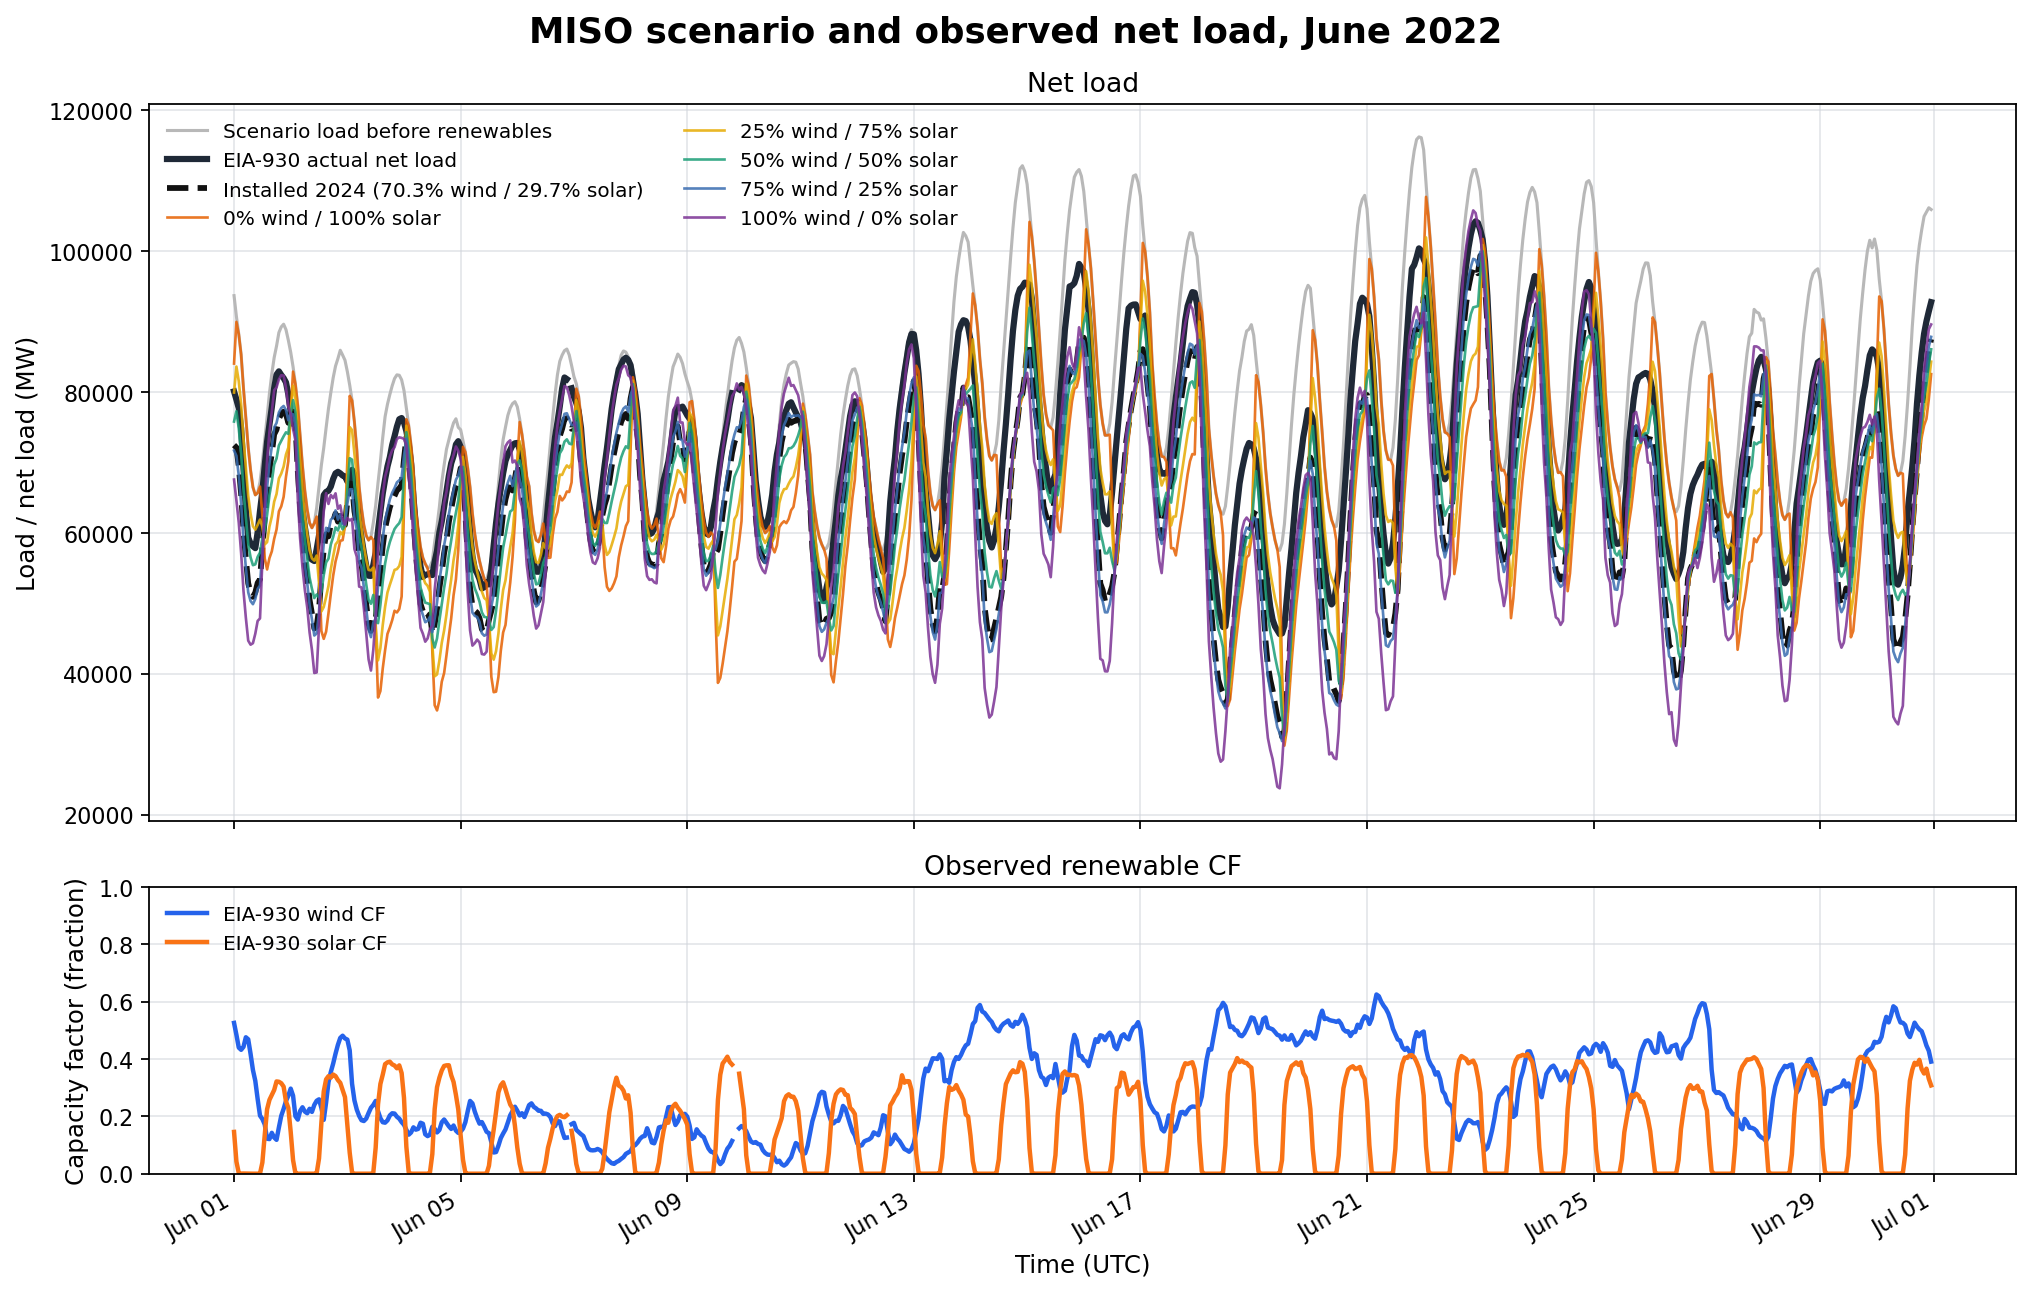

Wrote scenario/EIA plot to ../../data_outputs/data_flow/ba_scenario_metrics_generation/plots/MISO_2022-06-01_to_2022-07-01_scenario_vs_eia_actual_net_load_and_cf.png


In [8]:
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Keep scenario colors stable so wind-heavy and solar-heavy cases are easy to track.
SPLIT_SCENARIO_COLORS = {
    "split_w00_s100": "#E66101",
    "split_w25_s75": "#E6AB02",
    "split_w50_s50": "#1B9E77",
    "split_w75_s25": "#386CB0",
    "split_w100_s00": "#7B3294",
}

archive_installed_mix = scenario_specs.iloc[0]
archive_installed_label = f"Installed 2024 ({archive_installed_mix['wind_pct']:.1f}% wind / {archive_installed_mix['solar_pct']:.1f}% solar)"

SCENARIO_PLOT = (
    PLOT_DIR / "MISO_2022-06-01_to_2022-07-01_scenario_vs_eia_actual_net_load_and_cf.png"
)

# Apply the same half-open time window to scenarios and observations.
plot_scenarios = notebook_scenarios[
    notebook_scenarios["time_utc"].ge(plot_start) & notebook_scenarios["time_utc"].lt(plot_end)
]
plot_eia = eia_actual_net_load[
    eia_actual_net_load["time_utc"].ge(plot_start) & eia_actual_net_load["time_utc"].lt(plot_end)
]
assert len(plot_eia) == 720, "Expected 720 hourly timestamps in June 2022."
installed_rows = plot_scenarios[plot_scenarios["scenario"].eq(ARCHIVE_INSTALLED_SCENARIO)]

fig, (ax_net, ax_gen) = plt.subplots(
    2,
    1,
    figsize=(12.8, 8.2),
    dpi=160,
    sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1.0]},
)

# Upper panel: demand baseline, observed net load, and all modeled capacity portfolios.
ax_net.plot(
    installed_rows["time_utc"],
    installed_rows["load_mw"],
    color="#B8B8B8",
    linewidth=1.4,
    label="Scenario load before renewables",
)
ax_net.plot(
    plot_eia["time_utc"],
    plot_eia["eia930_net_load_mw"],
    color="#1f2937",
    linewidth=2.8,
    label="EIA-930 actual net load",
)

ax_net.plot(
    installed_rows["time_utc"],
    installed_rows["net_load_mw"],
    color="#111111",
    linewidth=2.6,
    linestyle="--",
    label=archive_installed_label,
)

for scenario, color in SPLIT_SCENARIO_COLORS.items():
    scenario_rows = plot_scenarios[plot_scenarios["scenario"].eq(scenario)]
    if not scenario_rows.empty:
        ax_net.plot(
            scenario_rows["time_utc"],
            scenario_rows["net_load_mw"],
            color=color,
            linewidth=1.2,
            alpha=0.85,
            label=SCENARIO_LABELS[scenario],
        )

ax_net.set(ylabel="Load / net load (MW)", title="Net load")
ax_net.legend(loc="upper left", ncol=2)
ax_net.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)

# Lower panel: observed resource availability, normalized to comparable 0-1 CF units.
ax_gen.plot(
    plot_eia["time_utc"],
    plot_eia["wind_actual_cf"],
    color="#2563eb",
    linewidth=2.0,
    label="EIA-930 wind CF",
)
ax_gen.plot(
    plot_eia["time_utc"],
    plot_eia["solar_actual_cf"],
    color="#f97316",
    linewidth=2.0,
    label="EIA-930 solar CF",
)
ax_gen.set(
    ylabel="Capacity factor (fraction)",
    ylim=(0, 1),
    xlabel="Time (UTC)",
    title="Observed renewable CF",
)
ax_gen.legend(loc="upper left")
ax_gen.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)

ax_gen.xaxis.set_major_locator(mdates.DayLocator(bymonthday=range(1, 31, 4), tz="UTC"))
ax_gen.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz="UTC"))
fig.suptitle("MISO scenario and observed net load, June 2022", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(SCENARIO_PLOT, bbox_inches="tight")
plt.show()

print(f"Wrote scenario/EIA plot to {SCENARIO_PLOT.as_posix()}")